Importing dependencies

In [12]:
from diffusers import DiffusionPipeline
import torch
import numpy as np
from PIL import Image

Load a pretrained diffusion model to cuda device using the DiffusionPipeline class from Hugging Face's diffusers library.

In [13]:
pipeline = DiffusionPipeline.from_pretrained("stable-diffusion-v1-5/stable-diffusion-v1-5")
pipeline.to("cuda") # Use GPU, much faster than CPU, change runtime type if in Colab

Loading pipeline components...:   0%|          | 0/7 [00:00<?, ?it/s]

StableDiffusionPipeline {
  "_class_name": "StableDiffusionPipeline",
  "_diffusers_version": "0.35.2",
  "_name_or_path": "stable-diffusion-v1-5/stable-diffusion-v1-5",
  "feature_extractor": [
    "transformers",
    "CLIPImageProcessor"
  ],
  "image_encoder": [
    null,
    null
  ],
  "requires_safety_checker": true,
  "safety_checker": [
    "stable_diffusion",
    "StableDiffusionSafetyChecker"
  ],
  "scheduler": [
    "diffusers",
    "PNDMScheduler"
  ],
  "text_encoder": [
    "transformers",
    "CLIPTextModel"
  ],
  "tokenizer": [
    "transformers",
    "CLIPTokenizer"
  ],
  "unet": [
    "diffusers",
    "UNet2DConditionModel"
  ],
  "vae": [
    "diffusers",
    "AutoencoderKL"
  ]
}

Testing image generation

  0%|          | 0/50 [00:00<?, ?it/s]

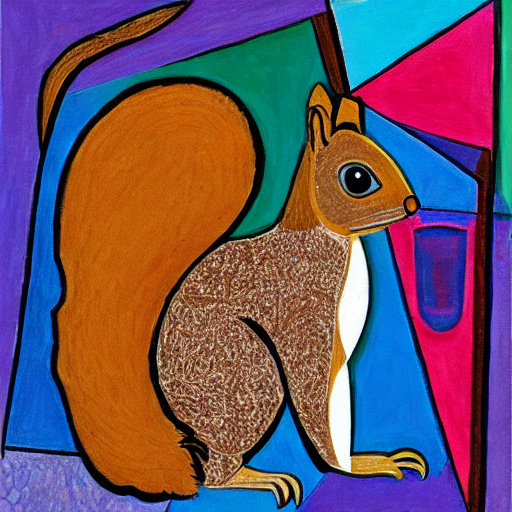

In [14]:
pipeline("An image of a squirrel in Picasso style").images[0]

Script to create image of random noise to be used as the initial image for the diffusion model. Then generating an image using our random noise image.

In [19]:
# Create a random noise array (values 0–255)
np.random.seed(42) # Using seed number to create same random pattern each time
noise = np.random.randint(0, 256, (512, 512, 3), dtype=np.uint8)

# Convert to image
img = Image.fromarray(noise)
img.save("random_noise.png")
img.show()

  0%|          | 0/50 [00:00<?, ?it/s]

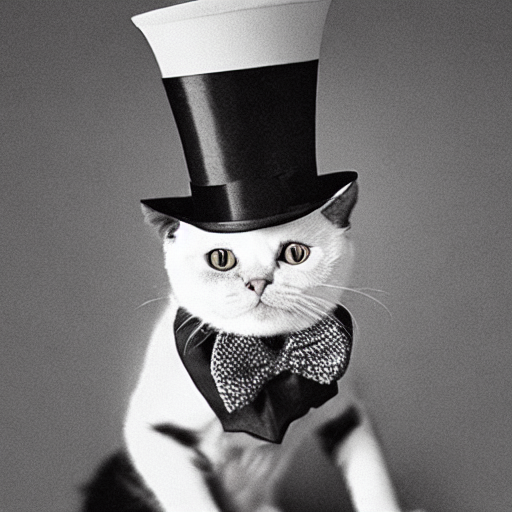

In [18]:
pipeline("An image of a cat wearing a top hat", image=img).images[0]